# Local LSEG/FinBERT strategy-run lineage audit

**Objective.** Determine whether the local frozen LSEG/FinBERT strategy results
contain another distinct positive strategy base that is missing from the final
evidence synthesis, or whether repeated result directories are duplicate evidence.

This notebook freezes ten existing run directories and reads only their aggregate
`manifest.json` and `metrics.json` files. It validates every metrics hash, assigns four
declared strategy families, collapses byte-identical payloads, and applies one descriptive
coverage floor: development and evaluation must each have at least 20 active sessions,
positive net return, and positive net Sharpe. The floor is an inventory aid, not a
promotion gate or statistical confirmation.

No corpus, score file, price, daily P&L, position, event, session-construction, or
headline text is read. No signal or return is constructed. The mid-cap and sector-33
LSEG regimes remain separate, and this audit does not compare FinBERT with Gemma.


In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

SEED = 20260806
np.random.seed(SEED)

ROOT = Path.cwd()
if not (ROOT / "final_experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "final_experiments").exists(), "Run from the repository root or final_experiments/."

OUTPUT = ROOT / "final_experiments/outputs/56_local_lseg_finbert_strategy_lineage"
OUTPUT.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 110)

RUN_DIRS = [
    "results/strategy_research/baselines/lseg-midcap-finbert-vader-v1-0b1d87ba5962",
    "results/strategy_research/baselines/lseg-midcap-finbert-vader-v1-2aa71b9a4648",
    "results/strategy_research/baselines/lseg-midcap-finbert-vader-v1-3c069b78b6e3",
    "results/strategy_research/baselines/lseg-midcap-finbert-vader-v1-e00c25d954e6",
    "results/strategy_research/baselines/lseg-midcap-finbert-vader-v1-ea963a725508",
    "results/strategy_research/baselines/lseg-midcap-finbert-vaderc-v2-299b11fa8e0a",
    "results/strategy_research/baselines/recent-news-midcap-finbert-event-v1-dfdd88113a5f",
    "results/strategy_research/baselines/recent-news-sector33-finbert-event-v1-4b9baebb01fa",
    "results/strategy_research/baselines/recent-news-sector33-finbert-event-v1-c8c31f457f1b",
    "results/strategy_research/finbert_strategy_v3/lseg-sector33-finbert-rank-reversal-v3-bb0a6569afe8",
]

FAMILY_BY_CONFIG_ID = {
    "lseg-midcap-finbert-vader-v1": "midcap_event_v1",
    "recent-news-midcap-finbert-event-v1": "midcap_event_v1",
    "lseg-midcap-finbert-vaderc-v2": "midcap_vaderc_v2",
    "recent-news-sector33-finbert-event-v1": "sector33_event_v1",
    "lseg-sector33-finbert-rank-reversal-v3": "sector33_rank_reversal_v3",
}
PRIMARY_ARM_BY_FAMILY = {
    "midcap_event_v1": "finbert",
    "midcap_vaderc_v2": "finbert",
    "sector33_event_v1": "finbert",
    "sector33_rank_reversal_v3": "finbert_rank_reversal",
}
CANONICAL_RUN_BY_FAMILY = {
    "midcap_event_v1": "recent-news-midcap-finbert-event-v1-dfdd88113a5f",
    "midcap_vaderc_v2": "lseg-midcap-finbert-vaderc-v2-299b11fa8e0a",
    "sector33_event_v1": "recent-news-sector33-finbert-event-v1-4b9baebb01fa",
    "sector33_rank_reversal_v3": "lseg-sector33-finbert-rank-reversal-v3-bb0a6569afe8",
}


def read_json(path: Path) -> dict:
    assert path.suffix == ".json", f"Aggregate-only boundary violated: {path}"
    return json.loads(path.read_text())


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def numeric(payload: dict, key: str) -> float:
    value = payload.get(key)
    return np.nan if value is None else float(value)


def git_commit() -> str:
    return subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
    ).stdout.strip()


run_rows = []
arm_rows = []
source_rows = []
for relative_dir in RUN_DIRS:
    run_dir = ROOT / relative_dir
    manifest_path = run_dir / "manifest.json"
    metrics_path = run_dir / "metrics.json"
    manifest = read_json(manifest_path)
    metrics = read_json(metrics_path)

    assert manifest["status"] == "completed"
    assert manifest["sample_status"] == "previously_explored"
    assert manifest["run_id"] == run_dir.name
    assert Path(manifest["outputs"]["metrics"]["path"]) == metrics_path.relative_to(ROOT)
    assert manifest["outputs"]["metrics"]["sha256"] == sha256(metrics_path)

    config_id = manifest["config"]["run"]["id"]
    assert config_id in FAMILY_BY_CONFIG_ID
    family = FAMILY_BY_CONFIG_ID[config_id]
    metrics_sha = sha256(metrics_path)
    run_rows.append(
        {
            "run_id": manifest["run_id"],
            "run_dir": relative_dir,
            "config_id": config_id,
            "family": family,
            "canonical_family_run": manifest["run_id"] == CANONICAL_RUN_BY_FAMILY[family],
            "config_sha256": manifest["input_identities"]["config_sha256"],
            "price_panel_sha256": manifest["input_identities"]["price_panel_sha256"],
            "score_artifact_sha256": manifest["input_identities"]["score_artifact_sha256"],
            "metrics_sha256": metrics_sha,
            "arm_count": len(metrics),
        }
    )
    for source_name, source_path in (("manifest", manifest_path), ("metrics", metrics_path)):
        source_rows.append(
            {
                "run_id": manifest["run_id"],
                "source": source_name,
                "path": str(source_path.relative_to(ROOT)),
                "sha256": sha256(source_path),
            }
        )

    for arm, period_payload in metrics.items():
        development = period_payload["development"]
        evaluation = period_payload["evaluation"]
        arm_rows.append(
            {
                "run_id": manifest["run_id"],
                "config_id": config_id,
                "family": family,
                "canonical_family_run": manifest["run_id"] == CANONICAL_RUN_BY_FAMILY[family],
                "primary_family_arm": arm == PRIMARY_ARM_BY_FAMILY[family],
                "metrics_sha256": metrics_sha,
                "arm": arm,
                "development_active_sessions": int(development["active_day_count_excluding_liquidation"]),
                "development_net_return": numeric(development, "cumulative_net_return"),
                "development_net_sharpe": numeric(development, "after_cost_sharpe"),
                "evaluation_active_sessions": int(evaluation["active_day_count_excluding_liquidation"]),
                "evaluation_net_return": numeric(evaluation, "cumulative_net_return"),
                "evaluation_net_sharpe": numeric(evaluation, "after_cost_sharpe"),
                "evaluation_breakeven_bps_per_side": numeric(
                    evaluation, "breakeven_cost_bps_per_side_approx"
                ),
            }
        )

run_inventory = pd.DataFrame(run_rows).sort_values(["family", "run_id"])
arm_inventory = pd.DataFrame(arm_rows).sort_values(["family", "run_id", "arm"])
source_files = pd.DataFrame(source_rows).sort_values(["run_id", "source"])

assert len(run_inventory) == 10
assert run_inventory["run_id"].is_unique
assert set(run_inventory["family"]) == set(CANONICAL_RUN_BY_FAMILY)
assert int(run_inventory["canonical_family_run"].sum()) == 4
assert len(source_files) == 20

run_inventory.to_csv(OUTPUT / "run_inventory.csv", index=False)
arm_inventory.to_csv(OUTPUT / "arm_inventory.csv", index=False)
source_files.to_csv(OUTPUT / "source_files.csv", index=False)

display(
    Markdown(
        f"Validated **{len(run_inventory)} run directories** and **{len(source_files)} aggregate files**. "
        "Every metrics payload matches its immutable manifest hash."
    )
)


Validated **10 run directories** and **20 aggregate files**. Every metrics payload matches its immutable manifest hash.

## Exact payloads and strategy families

Byte-identical metrics payloads are duplicate artifacts, not independent replications.
Config/run IDs are then collapsed into four declared economic families. The canonical
run is a lineage label only; no result is chosen from its Sharpe.


In [2]:
metric_groups = (
    run_inventory.groupby("metrics_sha256", as_index=False)
    .agg(
        run_directory_count=("run_id", "size"),
        run_ids=("run_id", lambda values: " | ".join(sorted(values))),
        config_ids=("config_id", lambda values: " | ".join(sorted(set(values)))),
        families=("family", lambda values: " | ".join(sorted(set(values)))),
    )
    .sort_values(["run_directory_count", "metrics_sha256"], ascending=[False, True])
)
metric_groups["exact_duplicate_payload"] = metric_groups["run_directory_count"] > 1
metric_groups.to_csv(OUTPUT / "metrics_payload_groups.csv", index=False)

arm_inventory["descriptive_floor_pass"] = (
    arm_inventory["development_active_sessions"].ge(20)
    & arm_inventory["evaluation_active_sessions"].ge(20)
    & arm_inventory["development_net_return"].gt(0)
    & arm_inventory["evaluation_net_return"].gt(0)
    & arm_inventory["development_net_sharpe"].gt(0)
    & arm_inventory["evaluation_net_sharpe"].gt(0)
)
arm_inventory.to_csv(OUTPUT / "arm_inventory.csv", index=False)

canonical_arms = arm_inventory.loc[arm_inventory["canonical_family_run"]].copy()
primary_family_rows = canonical_arms.loc[canonical_arms["primary_family_arm"]].copy()
assert len(primary_family_rows) == 4
assert primary_family_rows["family"].is_unique

family_counts = (
    run_inventory.groupby("family", as_index=False)
    .agg(
        run_directories=("run_id", "size"),
        unique_metrics_payloads=("metrics_sha256", "nunique"),
        unique_config_ids=("config_id", "nunique"),
    )
)
family_summary = family_counts.merge(
    primary_family_rows[
        [
            "family",
            "run_id",
            "arm",
            "development_active_sessions",
            "development_net_return",
            "development_net_sharpe",
            "evaluation_active_sessions",
            "evaluation_net_return",
            "evaluation_net_sharpe",
            "evaluation_breakeven_bps_per_side",
            "descriptive_floor_pass",
        ]
    ],
    on="family",
    how="left",
    validate="one_to_one",
).rename(columns={"run_id": "canonical_run_id", "arm": "primary_arm"})

assert int(family_summary["descriptive_floor_pass"].sum()) == 1
passing_family = family_summary.loc[family_summary["descriptive_floor_pass"], "family"].item()
assert passing_family == "midcap_event_v1"
assert CANONICAL_RUN_BY_FAMILY[passing_family] == "recent-news-midcap-finbert-event-v1-dfdd88113a5f"

family_summary.to_csv(OUTPUT / "family_summary.csv", index=False)

underpowered_positive = canonical_arms.loc[
    canonical_arms["evaluation_net_sharpe"].gt(0)
    & ~canonical_arms["descriptive_floor_pass"]
].copy()
assert len(underpowered_positive) == 1
assert underpowered_positive.iloc[0]["family"] == "midcap_vaderc_v2"
assert underpowered_positive.iloc[0]["arm"] == "finbert_magnitude"
assert int(underpowered_positive.iloc[0]["evaluation_active_sessions"]) == 5

display(metric_groups)
display(
    family_summary.style.format(
        {
            "development_net_return": "{:+.2%}",
            "development_net_sharpe": "{:+.3f}",
            "evaluation_net_return": "{:+.2%}",
            "evaluation_net_sharpe": "{:+.3f}",
            "evaluation_breakeven_bps_per_side": "{:+.2f}",
        }
    )
)


,metrics_sha256,run_directory_count,run_ids,config_ids,families,exact_duplicate_payload
3,e010c21bf9ed430f8248e358243f9d22c3869cdf08e6cbc74ffb667813a2d08e,4,lseg-midcap-finbert-vader-v1-0b1d87ba5962 | lseg-midcap-finbert-vader-v1-2aa71b9a4648 | lseg-midcap-finber...,lseg-midcap-finbert-vader-v1 | recent-news-midcap-finbert-event-v1,midcap_event_v1,True
0,a023b893cda33b4d7adc923d705c122056770167b6f10eeb1d3d983b107285ab,2,lseg-midcap-finbert-vader-v1-e00c25d954e6 | lseg-midcap-finbert-vader-v1-ea963a725508,lseg-midcap-finbert-vader-v1,midcap_event_v1,True
4,ebfe03b4b33e5a4cb14e9212ed5f2360fb06844287207eb679724b6e40d64eb7,2,recent-news-sector33-finbert-event-v1-4b9baebb01fa | recent-news-sector33-finbert-event-v1-c8c31f457f1b,recent-news-sector33-finbert-event-v1,sector33_event_v1,True
1,ac8993141e023f2450d90a83740f177f9dd55299a469157167ac9396d9dc4f8f,1,lseg-sector33-finbert-rank-reversal-v3-bb0a6569afe8,lseg-sector33-finbert-rank-reversal-v3,sector33_rank_reversal_v3,False
2,bcb3ff2b217b4d8146eb85a225f4f3b12fbc44efbacb4df1aea5556e502a7e52,1,lseg-midcap-finbert-vaderc-v2-299b11fa8e0a,lseg-midcap-finbert-vaderc-v2,midcap_vaderc_v2,False


,family,run_directories,unique_metrics_payloads,unique_config_ids,canonical_run_id,primary_arm,development_active_sessions,development_net_return,development_net_sharpe,evaluation_active_sessions,evaluation_net_return,evaluation_net_sharpe,evaluation_breakeven_bps_per_side,descriptive_floor_pass
0,midcap_event_v1,6,2,2,recent-news-midcap-finbert-event-v1-dfdd88113a5f,finbert,25,+3.42%,+0.780,37,+4.00%,+0.593,+16.52,True
1,midcap_vaderc_v2,1,1,1,lseg-midcap-finbert-vaderc-v2-299b11fa8e0a,finbert,1,-1.97%,-1.466,5,-0.14%,-0.104,+8.73,False
2,sector33_event_v1,2,1,1,recent-news-sector33-finbert-event-v1-4b9baebb01fa,finbert,92,-9.16%,-2.491,30,-5.04%,-3.682,-0.53,False
3,sector33_rank_reversal_v3,1,1,1,lseg-sector33-finbert-rank-reversal-v3-bb0a6569afe8,finbert_rank_reversal,92,-0.29%,-0.002,32,-14.47%,-10.719,-53.97,False


## Coverage plot

The left panel displays every arm in the four canonical family runs. Zero-trade arms
with undefined Sharpe are omitted from the plot but retained in the table. The right
panel shows how many directories carry each exact metrics payload.


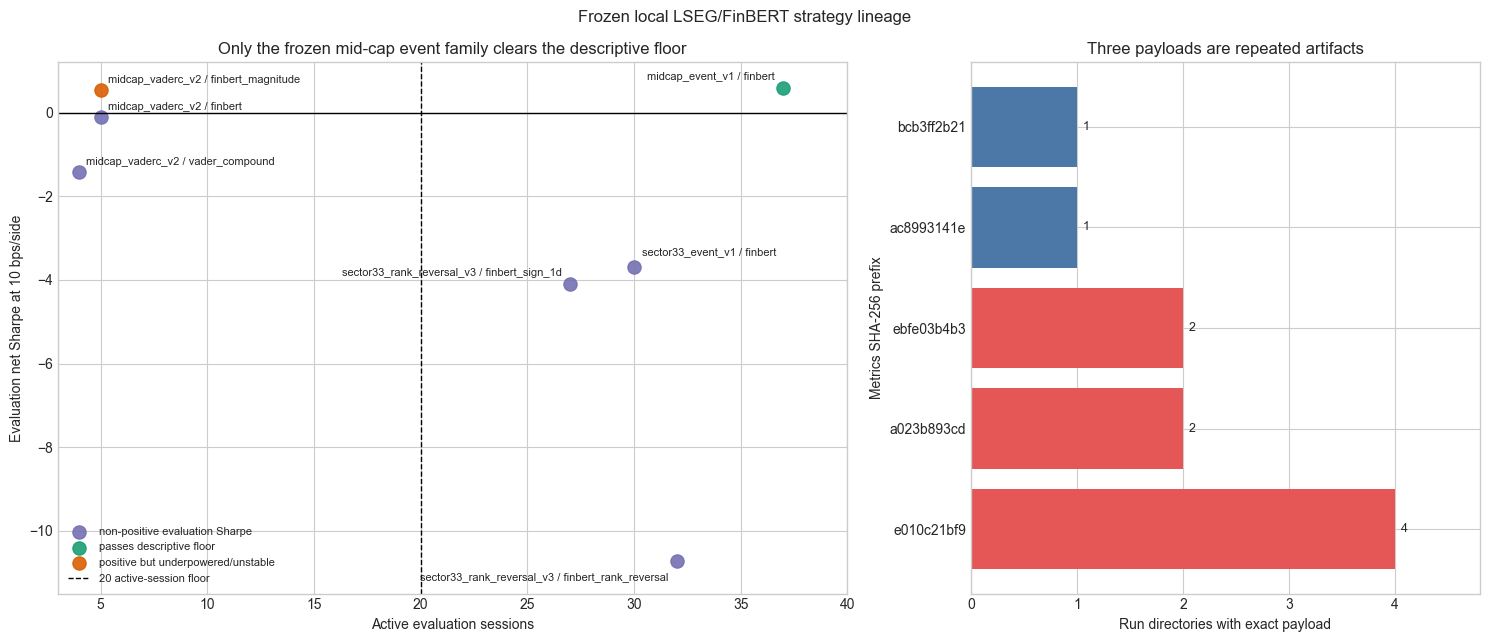

In [3]:
plot_arms = canonical_arms.loc[canonical_arms["evaluation_net_sharpe"].notna()].copy()
plot_arms["label"] = plot_arms["family"] + " / " + plot_arms["arm"]
plot_arms["status"] = np.select(
    [
        plot_arms["descriptive_floor_pass"],
        plot_arms["evaluation_net_sharpe"].gt(0),
    ],
    ["passes descriptive floor", "positive but underpowered/unstable"],
    default="non-positive evaluation Sharpe",
)
palette = {
    "passes descriptive floor": "#1b9e77",
    "positive but underpowered/unstable": "#d95f02",
    "non-positive evaluation Sharpe": "#7570b3",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.55, 1]})
for status, group in plot_arms.groupby("status"):
    axes[0].scatter(
        group["evaluation_active_sessions"],
        group["evaluation_net_sharpe"],
        s=90,
        color=palette[status],
        label=status,
        alpha=0.9,
    )
annotation_style = {
    "sector33_rank_reversal_v3 / finbert_rank_reversal": {"xytext": (-6, -14), "ha": "right"},
    "sector33_rank_reversal_v3 / finbert_sign_1d": {"xytext": (-6, 6), "ha": "right"},
    "sector33_event_v1 / finbert": {"xytext": (6, 8), "ha": "left"},
    "midcap_event_v1 / finbert": {"xytext": (-6, 6), "ha": "right"},
}
for _, row in plot_arms.iterrows():
    style = annotation_style.get(row["label"], {"xytext": (5, 5), "ha": "left"})
    axes[0].annotate(
        row["label"],
        (row["evaluation_active_sessions"], row["evaluation_net_sharpe"]),
        xytext=style["xytext"],
        textcoords="offset points",
        fontsize=8,
        ha=style["ha"],
    )
axes[0].axhline(0, color="black", lw=1)
axes[0].axvline(20, color="black", lw=1, ls="--", label="20 active-session floor")
axes[0].set_xlabel("Active evaluation sessions")
axes[0].set_ylabel("Evaluation net Sharpe at 10 bps/side")
axes[0].set_title("Only the frozen mid-cap event family clears the descriptive floor")
axes[0].set_xlim(3, 40)
axes[0].set_ylim(-11.5, 1.2)
axes[0].legend(fontsize=8, loc="lower left")

group_plot = metric_groups.copy()
group_plot["hash"] = group_plot["metrics_sha256"].str[:10]
group_colors = np.where(group_plot["exact_duplicate_payload"], "#e45756", "#4c78a8")
axes[1].barh(group_plot["hash"], group_plot["run_directory_count"], color=group_colors)
axes[1].set_xlabel("Run directories with exact payload")
axes[1].set_ylabel("Metrics SHA-256 prefix")
axes[1].set_title("Three payloads are repeated artifacts")
for index, value in enumerate(group_plot["run_directory_count"]):
    axes[1].text(value + 0.05, index, str(value), va="center", fontsize=9)
axes[1].set_xlim(0, group_plot["run_directory_count"].max() + 0.8)

fig.suptitle("Frozen local LSEG/FinBERT strategy lineage")
fig.tight_layout()
fig.savefig(OUTPUT / "strategy_lineage_and_coverage.png", dpi=180, bbox_inches="tight")
plt.show()


## Decision

The audit answers an evidence-coverage question, not a strategy-selection question. A
positive Sharpe with five active sessions does not become a candidate, and byte-identical
metrics do not become repeated validation.


In [4]:
decision = {
    "run_directories": int(len(run_inventory)),
    "exact_metrics_payloads": int(run_inventory["metrics_sha256"].nunique()),
    "exact_duplicate_payload_groups": int(metric_groups["exact_duplicate_payload"].sum()),
    "declared_strategy_families": int(family_summary["family"].nunique()),
    "canonical_arm_rows": int(len(canonical_arms)),
    "positive_evaluation_canonical_arms": int(canonical_arms["evaluation_net_sharpe"].gt(0).sum()),
    "positive_but_underpowered_or_unstable_canonical_arms": int(len(underpowered_positive)),
    "primary_families_passing_descriptive_floor": int(
        family_summary["descriptive_floor_pass"].sum()
    ),
    "only_passing_family": passing_family,
    "only_passing_canonical_run": CANONICAL_RUN_BY_FAMILY[passing_family],
    "n55_captures_only_passing_family": True,
    "another_distinct_positive_covered_base_omitted": False,
    "new_signal_constructed": False,
    "new_return_constructed": False,
    "strategy_promoted": False,
}

gates = pd.DataFrame(
    [
        {"gate": "all_manifest_metric_hashes_validate", "pass": True},
        {"gate": "exact_strategy_family_snapshot_present", "pass": len(family_summary) == 4},
        {"gate": "exactly_one_primary_family_passes_descriptive_floor", "pass": decision["primary_families_passing_descriptive_floor"] == 1},
        {"gate": "n55_captures_only_passing_family", "pass": decision["n55_captures_only_passing_family"]},
        {"gate": "another_distinct_positive_covered_base_omitted", "pass": decision["another_distinct_positive_covered_base_omitted"]},
        {"gate": "new_return_constructed", "pass": decision["new_return_constructed"]},
        {"gate": "strategy_promoted", "pass": decision["strategy_promoted"]},
    ]
)
gates.to_csv(OUTPUT / "gates.csv", index=False)

display(gates)
display(
    Markdown(
        f"""
### Result

- **Coverage:** {decision['run_directories']} frozen run directories collapse to
  **{decision['exact_metrics_payloads']} exact metrics payloads** and
  **{decision['declared_strategy_families']} declared strategy families**.
- **Duplicate evidence:** {decision['exact_duplicate_payload_groups']} metrics payloads
  appear in multiple run directories. They are lineage copies, not independent replications.
- **Only covered positive family:** the primary `midcap_event_v1` FinBERT arm is the sole
  family to have positive development and evaluation net return/Sharpe with at least 20
  active sessions in both periods. Notebook 55 already captures its canonical frozen run.
- **Apparent alternative:** the post-v1 `finbert_magnitude` arm has evaluation net Sharpe
  **{underpowered_positive.iloc[0]['evaluation_net_sharpe']:.3f}**, but trades only
  **{int(underpowered_positive.iloc[0]['evaluation_active_sessions'])}** evaluation sessions
  and has development Sharpe **{underpowered_positive.iloc[0]['development_net_sharpe']:.3f}**.
  It is not a usable base.
- **Decision:** no other distinct positive, adequately covered local LSEG/FinBERT base was
  omitted. This strengthens Notebook 55's role as the only historical strategy-shaped
  comparator in this run family; it does not strengthen its causal, statistical, or
  deployment claim and does not compare it with Gemma.
"""
    )
)

manifest = {
    "notebook": "56_local_lseg_finbert_strategy_lineage.ipynb",
    "status": "complete_aggregate_only_lineage_audit_no_new_returns",
    "seed": SEED,
    "git_commit_at_execution": git_commit(),
    "input_boundary": {
        "frozen_run_dirs": RUN_DIRS,
        "source_sha256": {
            row["path"]: row["sha256"] for row in source_files.to_dict("records")
        },
        "corpus_loaded": False,
        "score_artifact_loaded": False,
        "prices_loaded": False,
        "daily_pnl_loaded": False,
        "positions_loaded": False,
        "events_loaded": False,
        "headline_text_loaded": False,
        "licensed_text_emitted": False,
        "scorer_launched": False,
        "new_return_constructed": False,
    },
    "policy": {
        "family_by_config_id": FAMILY_BY_CONFIG_ID,
        "primary_arm_by_family": PRIMARY_ARM_BY_FAMILY,
        "canonical_run_by_family": CANONICAL_RUN_BY_FAMILY,
        "descriptive_floor": {
            "development_active_sessions_min": 20,
            "evaluation_active_sessions_min": 20,
            "development_net_return_positive": True,
            "evaluation_net_return_positive": True,
            "development_net_sharpe_positive": True,
            "evaluation_net_sharpe_positive": True,
        },
        "promotion_policy": False,
        "parameter_search_performed": False,
        "lseg_regimes_pooled": False,
    },
    "counts": {
        "run_rows": len(run_inventory),
        "arm_rows": len(arm_inventory),
        "canonical_arm_rows": len(canonical_arms),
        "family_rows": len(family_summary),
        "metrics_payload_groups": len(metric_groups),
        "source_rows": len(source_files),
    },
    "decision": decision,
    "limitations": [
        "The snapshot covers the ten frozen local LSEG/FinBERT strategy-research run directories declared above, not every notebook strategy or FNSPID result.",
        "Strategy-family mapping and canonical lineage labels are researcher-declared and are not statistical estimators.",
        "The descriptive floor prevents underpowered positive Sharpes from being called a base, but it is not a confidence interval or promotion rule.",
        "Byte-identical metrics establish duplicate output identity, not why the directories were created.",
        "The two mid-cap v1 metric payloads differ in calendar-spine accounting but share the same source inputs and active gross result; neither is independent validation.",
        "This FinBERT lineage audit does not compare scorer quality or performance with Gemma.",
        "No signal, allocation, price, daily path, or return was constructed.",
    ],
}

(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest["decision"], indent=2))


,gate,pass
0,all_manifest_metric_hashes_validate,True
1,exact_strategy_family_snapshot_present,True
2,exactly_one_primary_family_passes_descriptive_floor,True
3,n55_captures_only_passing_family,True
4,another_distinct_positive_covered_base_omitted,False
5,new_return_constructed,False
6,strategy_promoted,False



### Result

- **Coverage:** 10 frozen run directories collapse to
  **5 exact metrics payloads** and
  **4 declared strategy families**.
- **Duplicate evidence:** 3 metrics payloads
  appear in multiple run directories. They are lineage copies, not independent replications.
- **Only covered positive family:** the primary `midcap_event_v1` FinBERT arm is the sole
  family to have positive development and evaluation net return/Sharpe with at least 20
  active sessions in both periods. Notebook 55 already captures its canonical frozen run.
- **Apparent alternative:** the post-v1 `finbert_magnitude` arm has evaluation net Sharpe
  **0.545**, but trades only
  **5** evaluation sessions
  and has development Sharpe **-1.456**.
  It is not a usable base.
- **Decision:** no other distinct positive, adequately covered local LSEG/FinBERT base was
  omitted. This strengthens Notebook 55's role as the only historical strategy-shaped
  comparator in this run family; it does not strengthen its causal, statistical, or
  deployment claim and does not compare it with Gemma.


{
  "run_directories": 10,
  "exact_metrics_payloads": 5,
  "exact_duplicate_payload_groups": 3,
  "declared_strategy_families": 4,
  "canonical_arm_rows": 10,
  "positive_evaluation_canonical_arms": 2,
  "positive_but_underpowered_or_unstable_canonical_arms": 1,
  "primary_families_passing_descriptive_floor": 1,
  "only_passing_family": "midcap_event_v1",
  "only_passing_canonical_run": "recent-news-midcap-finbert-event-v1-dfdd88113a5f",
  "n55_captures_only_passing_family": true,
  "another_distinct_positive_covered_base_omitted": false,
  "new_signal_constructed": false,
  "new_return_constructed": false,
  "strategy_promoted": false
}


## Next step

Register this as a coverage control in Notebook 44 without adding another strategy row:
Notebook 55 already represents the only distinct local LSEG/FinBERT family clearing the
descriptive coverage floor. Keep historical tuning closed and continue the separately
frozen LSEG/Gemma prospective accumulation until its 120/60/20 gate can be evaluated.
